# Load the AIS data and visualize your first ship trajectory

## Import relevant libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Use pandas to load the AIS data
### Understanding the AIS dataset

The AIS (Automatic Identification System) dataset records the real-time navigation status of ships.  
Each row in the table represents a single AIS message transmitted by a vessel at a specific timestamp.  
Here’s what each column means:

- **IMO** – The International Maritime Organization (IMO) number, a unique identifier assigned to each ship.  
- **Date/Time** – The exact UTC time when the AIS message was recorded.  
- **Lat / Lng** – The latitude and longitude coordinates of the vessel’s position.  
- **Heading** – The direction the ship’s bow is pointing, measured in degrees from true north (0–360°).  
- **SOG (Speed Over Ground)** – The ship’s actual speed relative to the ground, measured in knots.  
- **COG (Course Over Ground)** – The ship’s actual course or path over the Earth’s surface, measured in degrees.  
- **Draught** – The vertical distance between the waterline and the bottom of the hull (keel), indicating how deeply the vessel sits in the water.  
- **Navigation status** – The operational condition of the ship (e.g., *Under Way*, *At Anchor*, *Moored*).

Together, these parameters describe the vessel’s movement and status at sea, enabling us to reconstruct its trajectory and analyze its navigation behavior.

In [2]:
df = pd.read_csv('../data/AIS_data.csv')

In [3]:
df.head()

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way


## Now we can filter a trajectory

### Filtering and visualizing a ship trajectory

In this step, we focus on **one specific ship (IMO 9595527)** and visualize its movement during a selected time window.

Here’s what the code does:



In [4]:
# Filter records for the specific ship (IMO = 9595527)
df_ship = df[df['IMO'] == 9595527].copy()
df_ship

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way
...,...,...,...,...,...,...,...,...,...
474,9595527,2021-10-05 00:15:00,34.257500,129.721944,47.0,23.1,46.4,14.1,Under Way
475,9595527,2021-10-05 00:18:00,34.268611,129.737222,53.0,23.1,52.6,14.1,Under Way
476,9595527,2021-10-05 00:20:00,34.279167,129.754167,52.0,22.9,52.0,14.1,Under Way
477,9595527,2021-10-05 00:21:00,34.279444,129.754444,52.0,22.9,52.0,14.1,Under Way


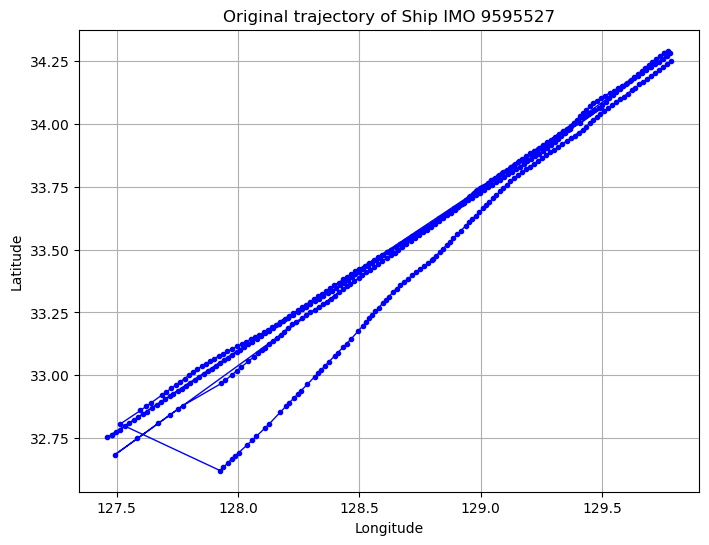

In [5]:
# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_ship['Lng'], df_ship['Lat'], marker='o', markersize=3, linewidth=1, color='blue')
# Add title and labels
plt.title('Original trajectory of Ship IMO 9595527', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## Splitting AIS Data into Multiple Trajectories

In real-world AIS datasets, ships may temporarily stop reporting their
positions due to signal loss, equipment shutdown, or port operations.
When this happens, the time gap between two consecutive AIS messages
can become very large.

To analyze vessel movement correctly, we usually treat each continuous
sequence of AIS messages as one trajectory. When the time gap is larger
than a user-defined threshold (for example, 24 hours), we start a new
trajectory segment.

The function below automatically:

1. Sorts AIS records in chronological order  
2. Converts timestamp strings into proper datetime objects  
3. Computes the time gap (in hours) between consecutive AIS points  
4. Assigns a new `traj_id` whenever the gap exceeds the threshold  
5. Returns the AIS dataframe with a new `traj_id` column  


In [6]:
def split_traj_by_gap(df_ship, time_col='Date/Time', gap_hours=24):
    """
    Split AIS records into separate trajectories whenever the observation gap
    between two consecutive AIS points exceeds a specified number of hours.
    A new trajectory ID (traj_id) is assigned to each continuous segment.
    
    Parameters
    ----------
    df_ship : pandas.DataFrame
        AIS dataframe containing records of a single ship.
    
    time_col : str
        Name of the timestamp column in df_ship.
    
    gap_hours : int or float
        Threshold (in hours) above which a new trajectory segment will be created.
    
    Returns
    -------
    pandas.DataFrame
        The original dataframe with an additional 'traj_id' column indicating
        the trajectory segment each AIS point belongs to.
    """

    # Ensure the dataframe is sorted in chronological order
    df_ship = df_ship.sort_values(time_col).copy()

    # Convert the timestamp column into pandas datetime format
    df_ship[time_col] = pd.to_datetime(df_ship[time_col])

    # Compute time difference (in hours) between consecutive AIS points
    df_ship["time_diff"] = df_ship[time_col].diff().dt.total_seconds() / 3600.0

    # Start a new trajectory whenever the gap exceeds the threshold
    # cumsum() increases by 1 each time the condition is True
    df_ship["traj_id"] = (df_ship["time_diff"] > gap_hours).cumsum() + 1

    # Remove helper column
    df_ship.drop(columns=["time_diff"], inplace=True)

    return df_ship
df_ship_split = split_traj_by_gap(df_ship, time_col='Date/Time', gap_hours=24)
df_ship_split

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status,traj_id
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way,1
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way,1
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way,1
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way,1
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way,1
...,...,...,...,...,...,...,...,...,...,...
474,9595527,2021-10-05 00:15:00,34.257500,129.721944,47.0,23.1,46.4,14.1,Under Way,4
475,9595527,2021-10-05 00:18:00,34.268611,129.737222,53.0,23.1,52.6,14.1,Under Way,4
476,9595527,2021-10-05 00:20:00,34.279167,129.754167,52.0,22.9,52.0,14.1,Under Way,4
477,9595527,2021-10-05 00:21:00,34.279444,129.754444,52.0,22.9,52.0,14.1,Under Way,4


### 📌 Plotting a Ship Trajectory (traj_id = 1)

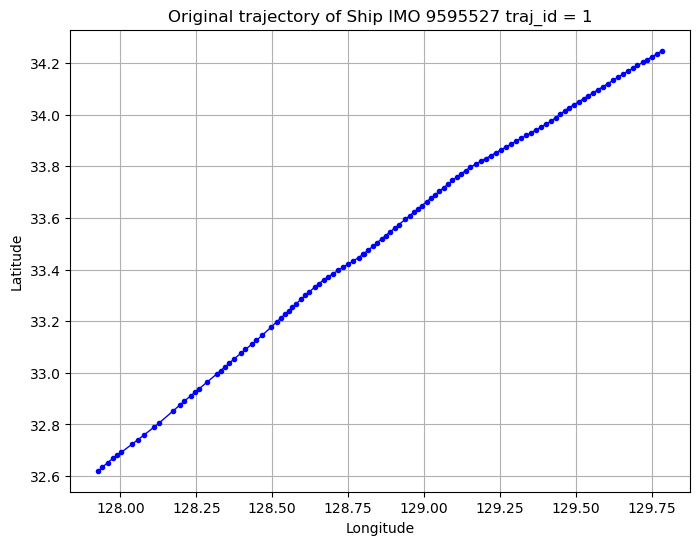

In [7]:
df_traj = df_ship_split[df_ship_split['traj_id']==1]

# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_traj['Lng'], df_traj['Lat'], marker='o', markersize=3, linewidth=1, color='blue')

# Add title and labels
plt.title('Original trajectory of Ship IMO 9595527 traj_id = 1', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## 🌬️ Interpolating Wind Data to AIS Trajectory Points

In this section, we match each AIS record with the corresponding wind field values
from the NetCDF dataset. The NetCDF file contains gridded wind information
(`northward_wind` and `eastward_wind`) on a 3-dimensional grid:
**time × latitude × longitude**.


## Data loading

### 📦 Understanding the Structure of a NetCDF Dataset (`ds`)

When we load a NetCDF (`.nc`) file using `xarray.open_dataset()`, the output is an
`xarray.Dataset` object. This object behaves like a labeled multi-dimensional
database, commonly used in oceanography, meteorology, and climate science.

Below is an explanation of each part of the dataset:

---

### 🔢 **Dimensions**

- **time** → 7296 hourly records  
- **latitude** → 24 grid points in the north–south direction  
- **longitude** → 39 grid points in the east–west direction  

This means the dataset forms a 3D grid:  
**time × latitude × longitude**

---

### 🧭 **Coordinates**
Each coordinate defines one axis of the grid:
- **time**: `2021-01-01 ... 2021-10-31T23:00:00`  
  → Hourly timestamps covering 10 months  
- **latitude**: `32.44 ... 35.31°`  
  → A small region (likely 3° range)  
- **longitude**: `126.1 ... 130.8°`  
  → Another 4°-wide region  

These coordinates allow xarray to align, select, and interpolate data
geospatially and temporally.

---

### 🌬️ **Data Variables**


Each variable has a complete 3D grid:

- **northward_wind** → wind blowing towards the north (v-component)
- **eastward_wind** → wind blowing towards the east (u-component)

At any given time and location, we can extract U/V wind components.

---

### 📑 **Attributes (Metadata)**
The dataset contains helpful metadata:

- **title**: “Global Ocean - Wind and Stress - Hourly - Reprocessed”  
  → This tells us the physical meaning of the dataset.
  
- **institution**: Royal Netherlands Meteorological Institute (KNMI)  
  → The data provider.

- **references**: Copernicus Marine Service documentation  
  → Where to find more details.

- **subset:productId, subset:datasetId**  
  → Internal dataset identifiers used by Copernicus.

- **subset:date**  
  → Date the subset was generated.

These metadata fields do *not* affect the data itself, but are useful for
tracking sources and ensuring reproducibility.

---

### 📝 Summary

This NetCDF file contains:

- Hourly wind data  
- For a regional grid (24 lat × 39 lon)  
- Covering Jan 2021 → Oct 2021  
- With two wind components (northward & eastward)

The dataset is well-suited for:
- Trajectory–weather matching  
- Weather routing  
- Ship performance and emissions calculations  
- Meteorological visualization  
- Scientific analysis requiring spatiotemporal wind fields

---




In [4]:
# load data
import xarray as xr

# read nc data
ds = xr.open_dataset("../data/cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_1763738218046.nc")
print(ds)


<xarray.Dataset>
Dimensions:         (time: 7296, latitude: 24, longitude: 39)
Coordinates:
  * time            (time) datetime64[ns] 2021-01-01 ... 2021-10-31T23:00:00
  * latitude        (latitude) float32 32.44 32.56 32.69 ... 35.06 35.19 35.31
  * longitude       (longitude) float32 126.1 126.2 126.3 ... 130.6 130.7 130.8
Data variables:
    northward_wind  (time, latitude, longitude) float32 ...
    eastward_wind   (time, latitude, longitude) float32 ...
Attributes:
    Conventions:       CF-1.11
    title:              Global Ocean - Wind and Stress - Hourly - Reprocessed...
    institution:       Royal Netherlands Meteorological Institute (KNMI)
    history:           N/A
    references:        Copernicus Marine Service Product User Manual CMEMS-TA...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  WIND_GLO_PHY_L4_MY_012_006
    subset:datasetId:  cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_202211
    subset:date:       2025



## interp_wind_to_traj() function:

1. **Prepare the AIS data**  
   Convert the `'Date/Time'` column into a proper `datetime` format so that
   xarray can interpret it as a time coordinate.

2. **Build interpolation targets**  
   For each AIS row, we create a triplet:  
   - time  
   - latitude  
   - longitude  
   These act as the input points for xarray’s multi-dimensional interpolation.

3. **Perform 3D interpolation**  
   Using `ds.interp(...)`, xarray automatically computes the wind values  
   at the specified times and geographic positions.

4. **Add interpolated wind to the AIS dataframe**  
   The function appends two new columns to the AIS trajectory table:
   - `northward_wind`
   - `eastward_wind`

This allows every AIS point to be paired with the best-matched wind conditions.
Such enriched datasets are essential in downstream applications such as:
weather routing, ship performance prediction, fuel-consumption analysis,
and emission estimation.

In [9]:
# Interpolate wind data
def interp_wind_to_traj(df_traj, ds):
    """
    Interpolate wind data (northward_wind, eastward_wind) from a NetCDF dataset
    to each AIS trajectory point using full 3D interpolation (time, lat, lon).

    Parameters
    ----------
    df_traj : pandas.DataFrame
        Must contain columns: 'Date/Time', 'Lat', 'Lng'
    ds : xarray.Dataset
        Must contain coordinates: time, latitude, longitude
        And data variables: northward_wind, eastward_wind

    Returns
    -------
    df : pandas.DataFrame
        Original dataframe with interpolated wind columns added
    """

    # copy to avoid changing original
    df = df_traj.copy()

    # convert AIS time column to datetime
    df["Date/Time"] = pd.to_datetime(df["Date/Time"])

    # Build interpolation points for xarray
    interp_points = {
        "time": ("points", df["Date/Time"].values),
        "latitude": ("points", df["Lat"].values),
        "longitude": ("points", df["Lng"].values)
    }

    # Perform interpolation
    interp_result = ds.interp(
        time=interp_points["time"],
        latitude=interp_points["latitude"],
        longitude=interp_points["longitude"],
        method="linear"
    )

    # Extract interpolated values
    df["northward_wind"] = interp_result["northward_wind"].values
    df["eastward_wind"] = interp_result["eastward_wind"].values

    return df


In [10]:
df_matched = interp_wind_to_traj(df_traj, ds)
df_matched

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status,traj_id,northward_wind,eastward_wind
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way,1,-5.148095,-1.881956
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way,1,-5.161406,-1.883402
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way,1,-5.176703,-1.883439
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way,1,-5.195897,-1.881984
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way,1,-5.218791,-1.879668
...,...,...,...,...,...,...,...,...,...,...,...,...
108,9595527,2021-04-25 03:38:00,32.680556,127.989167,223.0,21.7,224.4,12.0,Under Way,1,-8.234349,-4.996222
109,9595527,2021-04-25 03:41:00,32.668333,127.975278,223.0,21.7,224.1,12.0,Under Way,1,-8.210698,-5.003949
110,9595527,2021-04-25 03:44:00,32.652500,127.958056,219.0,21.5,219.5,12.0,Under Way,1,-8.191996,-5.006972
111,9595527,2021-04-25 03:48:00,32.633889,127.940000,219.0,21.6,219.6,12.0,Under Way,1,-8.171470,-5.022129
